## Brain Tumor Detection **[Testing and Evaluation]** 


### <b>A. Model Testing</b>


#### Loading our trained custom model


In [1]:
import os
from tensorflow.keras.models import load_model

models_dir = "../models"

I0000 00:00:1778143438.756611  110726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778143438.787753  110726 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778143439.866051  110726 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [7]:
available_models = []

for filename in os.listdir(models_dir):
    if filename.endswith((".h5", ".keras")):
        model_path = os.path.join(models_dir, filename)
        available_models.append(model_path)

print("Available models:")
for i, model_path in enumerate(available_models):
    print(f"Index {i}. {model_path}")

Available models:
Index 0. ../models/brain_tumor_vgg16_acc_0.9931_loss_0.0278.h5
Index 1. ../models/brain_tumor_vgg16_acc_0.9718_loss_0.0773.h5
Index 2. ../models/brain_tumor_vgg16_acc_0.9699_loss_0.0859.h5
Index 3. ../models/brain_tumor_vgg16_acc_0.9682_loss_0.0872.h5
Index 4. ../models/brain_tumor_vgg16_acc_0.9686_loss_0.0823.h5
Index 5. ../models/brain_tumor_vgg16_acc_0.9715_loss_0.0808.h5
Index 6. ../models/brain_tumor_vgg16_acc_0.9936_loss_0.0177.keras


In [8]:
idx = 6
model = load_model(available_models[idx])

W0000 00:00:1778143578.953300  110726 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


#### Defining the helper functions


1. Function to detect whether the given MRI image consists of tumor growth or not? **(tumor / notumor)** 
2. If yes then of which class?? **(pituitary / glioma / meningioma)** 


In [9]:
import numpy as np
from matplotlib import pyplot as plt
from keras.preprocessing.image import load_img, img_to_array

class_labels = ["pituitary", "glioma", "notumor", "meningioma"]

train_dir = "../data/brain-tumor-mri-dataset/Training"
test_dir = "../data/brain-tumor-mri-dataset/Testing"

In [10]:
def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == "notumor":
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis("off")
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

In [15]:
def return_random_test_samples(num_of_samples=5):
    """
    Function to return a list of random test image paths.
    """
    test_image_paths = []
    for root, dirs, files in os.walk(test_dir):
        for file in files:
            if file.endswith((".jpg", ".jpeg", ".png")):
                test_image_paths.append(os.path.join(root, file))
    
    # Return a random sample of test images (e.g., 5 images)
    return np.random.choice(test_image_paths, size=num_of_samples, replace=False)

#### Detecting Tumor on randomly selected MRI images from testing data


Testing on sample index 0: ../data/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_31.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


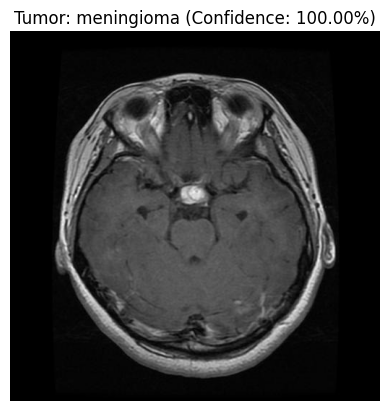

Testing on sample index 1: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_266.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


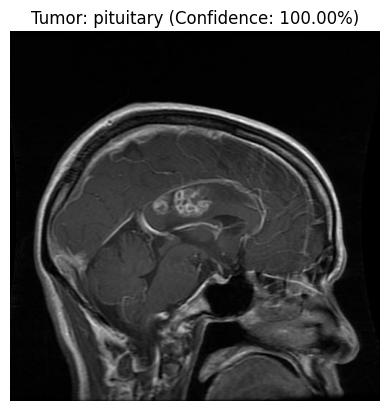

Testing on sample index 2: ../data/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_373.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


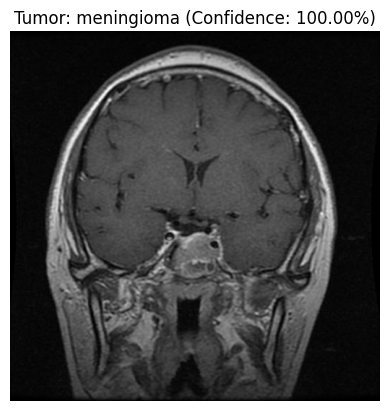

Testing on sample index 3: ../data/brain-tumor-mri-dataset/Testing/glioma/Te-gl_284.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


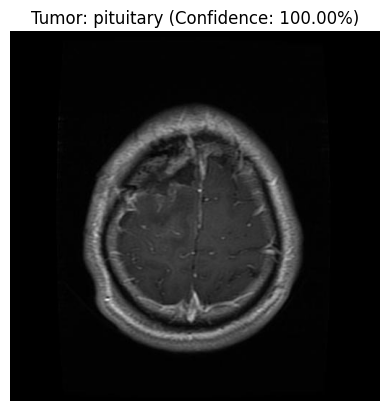

Testing on sample index 4: ../data/brain-tumor-mri-dataset/Testing/meningioma/Te-me_132.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


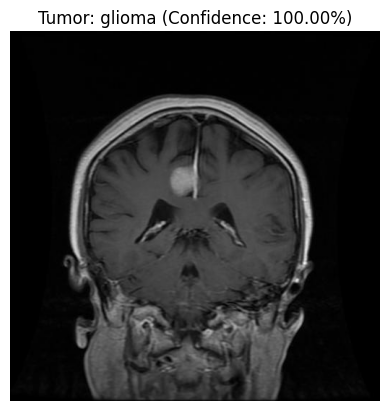

In [44]:
for i, sample in enumerate(return_random_test_samples()):
    print(f"Testing on sample index {i}: {sample}")
    detect_and_display(sample, model)

### <b>B. Model Evaluation</b>
